In this notebook, we will try to estimate the parameters of the superposition of two Thomas processes, under two assumptions:
- **Assumption 1**: The tree centers are generated by the same _Poisson_ process; $\lambda_{p,i} = \lambda_{p,j} = \lambda_p$
- **Assumption 2**: The larger the tree, the more offspring nodes we have; $\exists \mu \in \mathbb{R}^+\ \nu_i = \mu \sigma_i^2$

We'll be left with four parameters to estimate: $\theta = (\mu, \lambda_p, \sigma_1, \sigma_2)$

**Imports**

In [179]:
import sys
sys.path.append("../..")
from src.point_process import *
from src.utils import contrast, f4
import json

First, we will generate and display a superposition of such two thomas processes.

In [180]:
with open('../../parameters/superposition-m-13.json', 'r') as file:
    params = json.load(file)

In [181]:
W = params['W']
w, h = W
mu = params['mu']
lam_p = params['lam_p']
sig1, nu2 = params['thomas_1']['sig'], params['thomas_2']['nu']
nu1, sig2 = mu*sig1**2, np.sqrt(nu2/mu)

In [182]:
thomas_process1 = ThomasProcess(lam_p, nu1, sig1)
parents1, points_thomas1 = thomas_process1.generate(W, seed=46)
thomas_process2 = ThomasProcess(lam_p, nu2, sig2)
parents2, points_thomas2 = thomas_process2.generate(W, seed=47)
points_sup = np.concatenate([points_thomas1, points_thomas2])

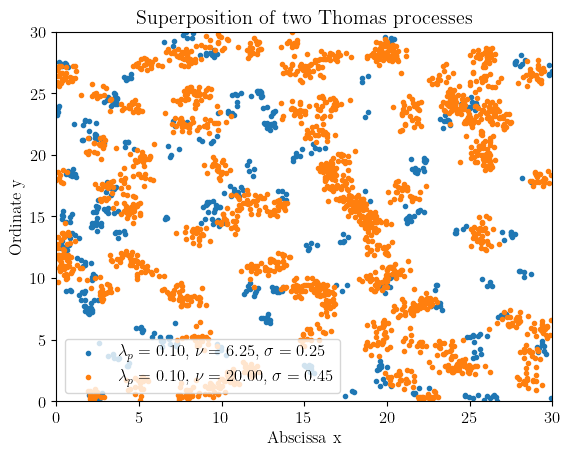

In [183]:
display_superposition([points_thomas1, points_thomas2], 
                      window=W, 
                      title="Superposition of two Thomas processes", 
                      labels=[fr'$\lambda_p = {lam_p: .2f}$, $\nu = {nu1: .2f}$, $\sigma = {sig1: .2f}$', 
                              fr'$\lambda_p = {lam_p: .2f}$, $\nu = {nu2: .2f}$, $\sigma = {sig2: .2f}$'])

In [184]:
threshold = 0.2
r_values = np.linspace(threshold, w/4, 1000)
I_values = periodogram_tapering(points_sup, W, r_values, taper_triangle)  # Estimate the Fourier transform

**Theoretical expression of $f_{\text{sup}}$**

Using the assumptions from the first paragraph, we find the Fourier transform of the superposition of two _Thomas_ processes:
$$
\begin{align}
f_{\text{sup}}(k) &= \lambda_p \mu \left( \sigma_1^2 + \mu \sigma_1^4 \exp \left( -4\pi^2 \sigma_1^2 k^2 \right) + \sigma_2^2 + \mu \sigma_2^4 \exp \left( -4\pi^2 \sigma_2^2 k^2 \right) \right) \\
&= \hat{\lambda} + \lambda_p \mu^2 \sigma_1^4 \exp \left( -4\pi^2 \sigma_1^2 k^2 \right) + \lambda_p\mu^2\sigma_2^4 \exp \left( -4\pi^2 \sigma_2^2 k^2\right) \\
&= \hat{\lambda} + \lambda_p \mu^2 \sigma_1^4 \exp \left( -4\pi^2 \sigma_1^2 k^2 \right) + \lambda_p\nu_2^2 \exp \left( -4\pi^2 \frac{\nu_2}{\mu} k^2 \right) 

\end{align}
$$

In [185]:
lam_hat = intensity(points_sup, W)

In [186]:
lam_p*(nu1 + nu2)

2.625

In [187]:
lam_hat

2.8377777777777777

In [188]:
def f_theo_sup(theta: list[float], r: float) -> float:
    """
    Compute the theoretical value of the Fourier transform of a superposition of two _Thomas_ processes under two assumptions:
    - **Assumption 1**: The tree centers are generated by the same _Poisson_ process.
    - **Assumption 2**: The larger the tree, the more offspring nodes we have.

    `theta` is the vector [mu, lam_p, sig1, nu2]
    """
    mu, lam_p, sig1, nu2 = theta
    return lam_p*(mu*sig1**2 + nu2) + (lam_hat/(mu*sig1**2 + nu2))*(mu**2*sig1**4*np.exp(-4*np.pi**2*sig1**2*r**2) + nu2**2*np.exp(-4*np.pi**2*nu2*r**2/mu))

Let's plot it for our real $\theta$, to see if it really looks like a Fourier transform.

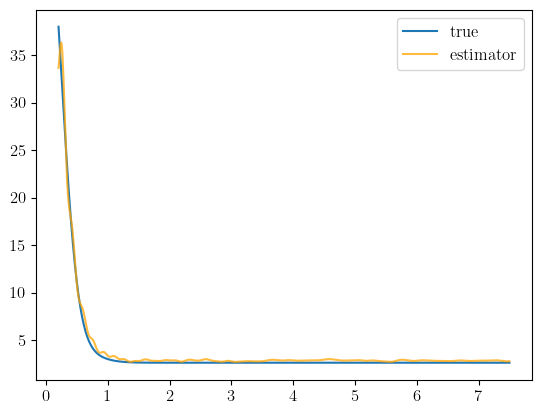

In [189]:
theta_real = [mu, lam_p, sig1, nu2]
plt.plot(r_values, f_theo_sup(theta_real, r_values), label='true')
plt.plot(r_values, I_values, linestyle='-', color='orange', label='estimator', alpha=.75)
plt.legend()
plt.show()

In [190]:
def contrast_aux(theta):  # Auxiliary contrast function that takes theta as a parameter
    g_theo_list = f_theo_sup(theta, r_values)
    dr = r_values[1] - r_values[0]
    return contrast(I_values, g_theo_list, dr)

In [191]:
def rmse(y_true, y_pred):
    return np.sqrt(np.sum((y_true - y_pred)**2))

In [192]:
from sklearn.model_selection import ParameterGrid

mu_values = np.linspace(1, 200, 5)
lamp_values = np.linspace(0.01, 0.2, 5)
sig1_values = np.linspace(0.1, 1, 5)
nu2_values = np.linspace(1, 50, 5)

param_grid = ParameterGrid({'mu': mu_values, 'lam_p': lamp_values, 'sig1': sig1_values, 'nu2': nu2_values})
rmse_min, result_min, theta0_min = float('inf'), None, None

for params in param_grid:
    theta0 = list(params.values())  # Initial guess
    bounds = [(1e-5, None)]*4 # Positivity constraints

    result = minimize(contrast_aux, theta0, method='L-BFGS-B', bounds=bounds)
    rmse_ = rmse(theta_real, result.x)
    if rmse_ < rmse_min:
        rmse_min, result_min, theta0_min = rmse_, result.x, theta0

In [193]:
def mape(y_true, y_pred):
    return abs((y_true - y_pred)/y_true)

In [194]:
mape_list = [mape(param_true, param_pred) for param_true, param_pred in zip(theta_real, result_min)]

print([f'{100*x: .2f} %' for x in mape_list])

[' 2.17 %', ' 11.37 %', ' 4.78 %', ' 0.56 %']


In [195]:
mu_hat, lamp_hat, sig1_hat, nu2_hat = result_min

In [196]:
nu1_hat, sig2_hat = mu_hat*sig1_hat**2, np.sqrt(nu2_hat/mu_hat)

In [197]:
print(f'mu: {mu: .2f}, mu_hat: {mu_hat: .2f}, mape: {mape(mu, mu_hat)*100: .2f}%')
print(f'lam_p: {lam_p: .3f}, lamp_hat: {lamp_hat: .3f}, mape: {mape(lam_p, lamp_hat)*100: .2f}%')
print(f'sig1: {sig1: .2f}, sig1_hat: {sig1_hat: .2f}, mape: {mape(sig1, sig1_hat)*100: .2f}%')
print(f'sig2: {sig2: .2f}, sig2_hat: {sig2_hat: .2f}, mape: {mape(sig2, sig2_hat)*100: .2f}%')
print(f'nu1: {nu1: .2f}, nu1_hat: {nu1_hat: .2f}, mape: {mape(nu1, nu1_hat)*100: .2f}%')
print(f'nu2: {nu2: .2f}, nu2_hat: {nu2_hat: .2f}, mape: {mape(nu2, nu2_hat)*100: .2f}%')

mu:  100.00, mu_hat:  102.17, mape:  2.17%
lam_p:  0.100, lamp_hat:  0.111, mape:  11.37%
sig1:  0.25, sig1_hat:  0.24, mape:  4.78%
sig2:  0.45, sig2_hat:  0.44, mape:  1.35%
nu1:  6.25, nu1_hat:  5.79, mape:  7.37%
nu2:  20.00, nu2_hat:  19.89, mape:  0.56%


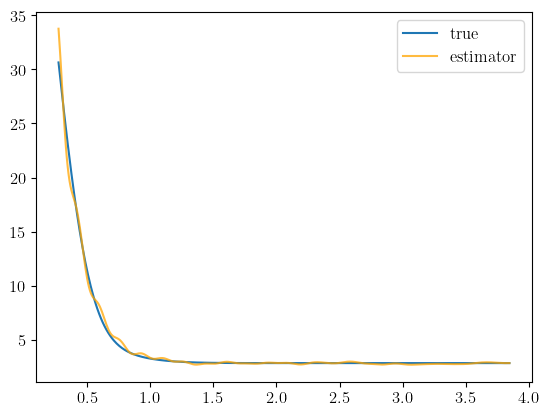

In [198]:
theta_est = [mu_hat, lamp_hat, sig1_hat, nu2_hat]
plt.plot(r_values[10:-500], f_theo_sup(theta_est, r_values)[10:-500], label='true')
plt.plot(r_values[10:-500], I_values[10:-500], linestyle='-', color='orange', label='estimator', alpha=.75)
plt.legend()
plt.show()